# Tomografia quântica para N qubits: versão generalizada


In [ ]:
# Código para resolver o problema de tomografia quântica para N q-bits.
import numpy as np
from scipy.optimize import minimize, least_squares
from scipy.linalg import sqrtm
import matplotlib.pyplot as plt
import cvxpy as cp
import itertools   
from itertools import product
import time  
from tqdm import tqdm    

In [13]:
class QuantState:
    def __init__(self, estado):
        """
        Aceita um vetor 1D (estado puro) ou uma matriz 2D (matriz densidade / estado misto).
        """
        estado = np.array(estado, dtype=complex)

        if estado.ndim == 1:
            norma = np.linalg.norm(estado)
            psi = estado / norma
            self.rho = np.outer(psi, psi.conj())

        elif estado.ndim == 2:
            if estado.shape[0] != estado.shape[1]:
                raise ValueError("A matriz densidade deve ser quadrada.")
            traco = np.trace(estado)
            self.rho = estado / traco

        # Preciso definir condições para dimensões maiores
        else:
            raise ValueError("O estado deve ser um vetor 1D (|psi>) ou matriz 2D (rho).")

    def measure(self, obs):
        """
        Mede o estado em relação a um observável (matriz hermitiana).
        Retorna o valor esperado <obs> = Tr(rho * obs).
        """
        return np.trace(self.rho @ obs).real

In [14]:
def parametros_para_T_geral(params, n_qubits):
    """Constrói a matriz triangular inferior T para N qubits (D = 2^N)."""
    D = 2**n_qubits
    li, lj = np.tril_indices(D, k=-1)          # índices abaixo da diagonal
    n_off = len(li)                            # D(D-1)/2 elementos complexos

    T = np.zeros((D, D), dtype=complex)
    T[np.arange(D), np.arange(D)] = params[:D]
    T[li, lj] = params[D:D + n_off] + 1j * params[D + n_off:]
    return T


def parametros_para_rho_geral(params, n_qubits):
    """Gera rho para qualquer número de qubits."""
    T = parametros_para_T_geral(params, n_qubits)
    T_dag_T = T.conj().T @ T
    traco = np.trace(T_dag_T).real             # [ALTERADO] .real (o traço de T†T é real)

    if np.isclose(traco, 0):
        D = 2**n_qubits
        return np.eye(D, dtype=complex) / D

    return T_dag_T / traco

In [15]:
# Para resolver usando mínimos quadrados do Scipy
def funcao_de_custo_geral(params, mediadores_T, dados_exp, n_qubits):
    rho_candidato = parametros_para_rho_geral(params, n_qubits)
    previsoes = np.einsum('ij,mji->m', rho_candidato, mediadores_T).real
    return previsoes - dados_exp

In [16]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)


# Gera as 4**n - 1 strings de Pauli (todas menos I⊗...⊗I) via produto de Kronecker.
def gerar_paulis(n_qubits):
    I = np.eye(2, dtype=complex)
    base = [I, sigma_x, sigma_y, sigma_z]
    saida = []
    for combo in itertools.product(base, repeat=n_qubits):
        P = combo[0]
        for c in combo[1:]:
            P = np.kron(P, c)
        saida.append(P)
    return saida[1:]        # remove a identidade (o valor esperado dela é sempre 1)


# Fidelidade entre duas matrizes densidade: F = (Tr sqrt( sqrt(A) B sqrt(A) ))^2
def sqrt_psd(A):
    w, V = np.linalg.eigh((A + A.conj().T) / 2)
    return (V * np.sqrt(np.clip(w, 0, None))) @ V.conj().T

def fidelidade(rho_a, rho_b):
    sa = sqrt_psd(rho_a)
    return np.real(np.trace(sqrt_psd(sa @ rho_b @ sa)))**2

In [24]:
"""Exemplo apenas para teste do algoritmo"""
np.random.seed(41321)  # Para reprodutibilidade
mediadores_Q1 = [sigma_x,  sigma_y, sigma_z]


unk_state1 = QuantState([2/np.sqrt(5), 1/np.sqrt(5)])
q1_medidos = [unk_state1.measure(sigma_x), unk_state1.measure(sigma_y), unk_state1.measure(sigma_z)]
n1_qubits = 1
print("Medidas experimentais:", q1_medidos)


num_params = (2**n1_qubits)**2 # 4 parametros
chute_inicial = np.random.randn(num_params)

rho2 = round(sum(i**2 for i in q1_medidos), 8)
print("Soma das medidas ao quadrado:", rho2)
if  rho2 > 1:
    print(rho2)
    print("A soma das medidas é maior que 1, o estado reconstruído não é físico.")

resultado = least_squares(
    funcao_de_custo_geral, 
    x0=chute_inicial, 
    args=(mediadores_Q1, q1_medidos, n1_qubits), # n1_qubits = 1
)

rho_reconstruido = parametros_para_rho_geral(resultado.x, n_qubits=n1_qubits)


print("Rho Reconstruído 1:\n", np.round(rho_reconstruido, 3))


print("Os parâmetros do rho reconstruído são:", np.trace(rho_reconstruido @ sigma_x), np.trace(rho_reconstruido @ sigma_y), np.trace(rho_reconstruido @ sigma_z)) 

print("Fidelidade entre o estado reconstruído e o estado original:", fidelidade(rho_reconstruido, unk_state1.rho))



Medidas experimentais: [np.float64(0.8000000000000004), np.float64(0.0), np.float64(0.6000000000000003)]
Soma das medidas ao quadrado: 1.0
Rho Reconstruído 1:
 [[0.8+0.j 0.4+0.j]
 [0.4-0.j 0.2+0.j]]
Os parâmetros do rho reconstruído são: (0.7999999962306282+0j) (-1.0275041189522281e-44+0j) (0.6000000035384988+0j)
Fidelidade entre o estado reconstruído e o estado original: 0.9999999995538018


Rho Reconstruído 1:
 [[0.602+0.j  0.35 -0.2j]
 [0.35 +0.2j 0.398+0.j ]]
Rho Reconstruído 2:
 [[0.368+0.j  0.35 -0.2j]
 [0.35 +0.2j 0.632+0.j ]]
(0.70000003451827+0j) (0.7000000068037145+0j)
(0.4000000197248258+0j) (0.40000000388779544+0j)


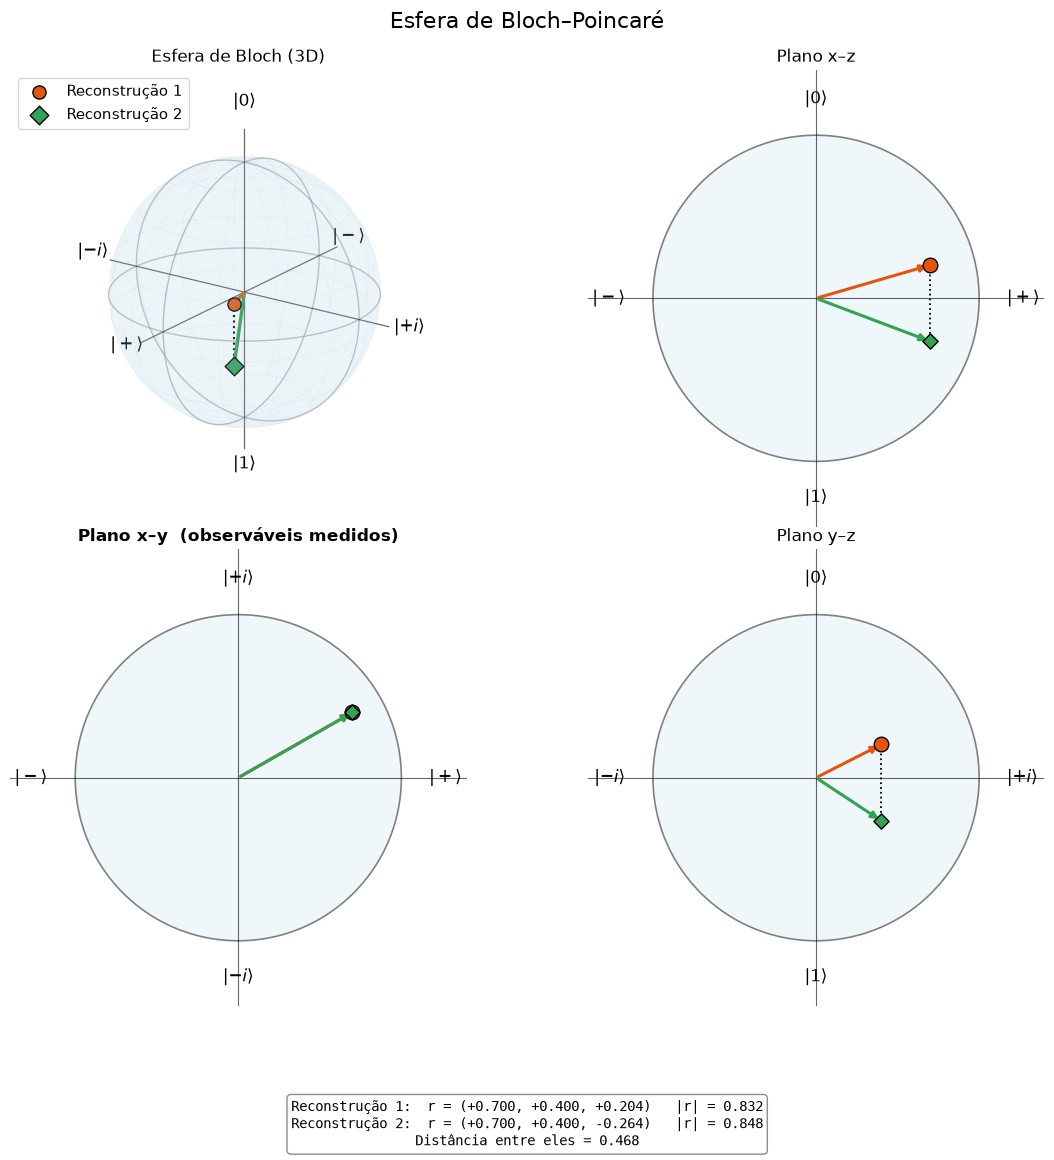

In [ ]:
"""Exemplo para ilustrar a não unicidade da reconstrução de estados quânticos a partir de medidas incompletas."""

np.random.seed(413453432)  # Para reprodutibilidade

mediadores_Q2 = [sigma_x, sigma_y]


q_medidos1 = [0.7,0.4]
q_medidos2 = [0.7,0.4]
n2_qubits = 1

num_params = (2**n2_qubits)**2 
chute_inicial1 = np.random.randn(num_params)
chute_inicial2 = np.random.randn(num_params)




resultado1 = least_squares(
    funcao_de_custo_geral, 
    x0=chute_inicial1, 
    args=(mediadores_Q2, q_medidos1, n2_qubits), # n2_qubits = 1
)

resultado2 = least_squares(
    funcao_de_custo_geral, 
    x0=chute_inicial2, 
    args=(mediadores_Q2, q_medidos2, n2_qubits), # n2_qubits = 1
)

rho_reconstruido1 = parametros_para_rho_geral(resultado1.x, n_qubits=n2_qubits)
rho_reconstruido2 = parametros_para_rho_geral(resultado2.x, n_qubits=n2_qubits)

print("Rho Reconstruído 1:\n", np.round(rho_reconstruido1, 3))
print("Rho Reconstruído 2:\n", np.round(rho_reconstruido2, 3))

print(np.trace(rho_reconstruido1 @ sigma_x), np.trace(rho_reconstruido2 @ sigma_x))
print(np.trace(rho_reconstruido1 @ sigma_y), np.trace(rho_reconstruido2 @ sigma_y))

from bloch_reconstrucao import plotar_bloch   # ou cole as funções no notebook

plotar_bloch(
    [rho_reconstruido1, rho_reconstruido2],
    rotulos=["Reconstrução 1", "Reconstrução 2"],
    medidos=("x", "y"),          # destaca o plano dos observáveis que você mediu
    salvar="bloch_reconstrucoes.png",
)

In [19]:
""" Exemplo para mais de 1-qubit """
np.random.seed(74564089)  # Para reprodutibilidade
n3_qubits = 5         
D = 2**n3_qubits
np.random.seed(60)

todos_Q = gerar_paulis(n3_qubits)


n_medidas = len(todos_Q)
mediadores_Q3 = todos_Q[:n_medidas]          


unk_state = QuantState(np.random.randn(D) + 1j * np.random.randn(D))

sigma_ruido = 0.0        # desvio padrão do ruído gaussiano (ex.: 0.01 para simular ruído)
q_medidos3 = np.array([unk_state.measure(Q) for Q in mediadores_Q3])
q_medidos3 = q_medidos3 + np.random.normal(0, sigma_ruido, size=len(q_medidos3))


# Para N qubits: soma dos quadrados dos valores esperados de Pauli <= 2**N - 1.
limite = 2**n3_qubits - 1
soma_q2 = np.sum(q_medidos3**2)
if soma_q2 > limite + 1e-9:
    print(f"A soma dos quadrados das medidas ({soma_q2:.3f}) é maior que {limite}: "
          "os dados não correspondem a um estado físico.")


num_params = (2**n3_qubits)**2
chute_inicial = np.random.randn(num_params)


mediadores_T3 = np.array(mediadores_Q3).transpose(0, 2, 1)

t0 = time.time() # Tempo de execução da otimização 
resultado1 = least_squares(
    funcao_de_custo_geral,
    x0=chute_inicial,
    args=(mediadores_T3, q_medidos3, n3_qubits),   # mediadores_T no lugar de mediadores_Q
)


print(f"Tempo de uma otimização: {time.time() - t0:.2f} s")   

rho_reconstruido1 = parametros_para_rho_geral(resultado1.x, n_qubits=n3_qubits)



if n3_qubits <= 2:
    print("Rho Reconstruído 1:\n", np.round(rho_reconstruido1, 3))



for i in range(min(len(mediadores_Q3), 4)):
    print(f"Q[{i}]: medido = {q_medidos3[i]:+.4f} | "
          f"rec.1 = {np.trace(rho_reconstruido1 @ mediadores_Q3[i]).real:+.4f} | ")


print("\nCusto final (0.5*soma dos resíduos^2):", resultado1.cost)
print("Fidelidade com o estado verdadeiro:",
      round(fidelidade(unk_state.rho, rho_reconstruido1), 6))



Tempo de uma otimização: 29.97 s
Q[0]: medido = +0.1033 | rec.1 = +0.1033 | 
Q[1]: medido = +0.0621 | rec.1 = -0.0621 | 
Q[2]: medido = +0.1286 | rec.1 = +0.1286 | 
Q[3]: medido = -0.0745 | rec.1 = -0.0745 | 

Custo final (0.5*soma dos resíduos^2): 1.7501181565460188e-10
Fidelidade com o estado verdadeiro: 0.000999


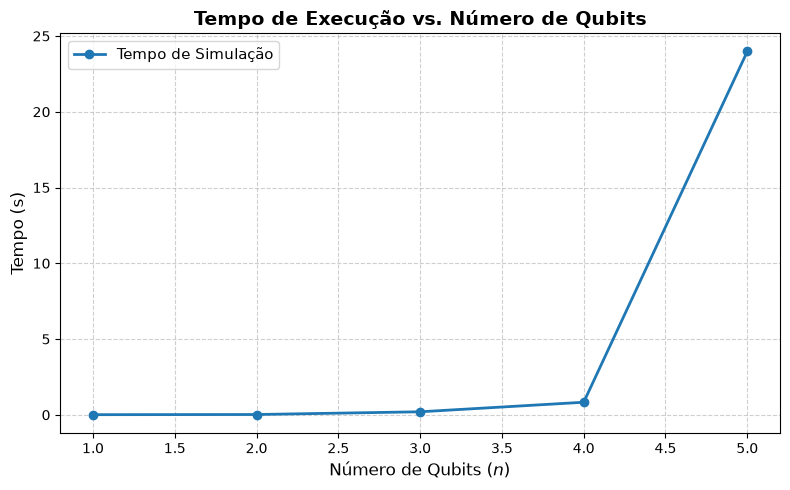

In [20]:
"""Teste para plotar gráfico de n qubits x tempo"""
np.random.seed(60)
n_qubits_list = [1, 2, 3, 4, 5] # Vou deixar para 5-qubits no max pelo tempo
tempo_list = []

for n_qubits in n_qubits_list:
    D = 2**n_qubits

    todos_Q = gerar_paulis(n_qubits)


    n_medidas = len(todos_Q)
    mediadores_Q4 = todos_Q[:n_medidas]          


    unk_state = QuantState(np.random.randn(D) + 1j * np.random.randn(D))

    sigma_ruido = 0.0        # desvio padrão do ruído gaussiano (ex.: 0.01 para simular ruído)
    q_medidos4 = np.array([unk_state.measure(Q) for Q in mediadores_Q4])
    q_medidos4 = q_medidos4 + np.random.normal(0, sigma_ruido, size=len(q_medidos4))



    num_params = (2**n_qubits)**2
    chute_inicial = np.random.randn(num_params)


    mediadores_T4 = np.array(mediadores_Q4).transpose(0, 2, 1)

    t0 = time.time()   
    resultado = least_squares(
        funcao_de_custo_geral,
        x0=chute_inicial,
        args=(mediadores_T4, q_medidos4, n_qubits),   # [ALTERADO] mediadores_T4 no lugar de mediadores_Q4
    )

    tempo_list.append(time.time() - t0)   # [NOVO]
         
    pass
plt.figure(figsize=(8, 5))

# Plotagem do gráfico de tempo de execução vs. número de qubits
plt.plot(
    n_qubits_list,
    tempo_list,
    marker='o',
    color='#1f77b4',
    linestyle='-',
    linewidth=2,
    label='Tempo de Simulação',
)

plt.title('Tempo de Execução vs. Número de Qubits', fontsize=14, fontweight='bold')
plt.xlabel('Número de Qubits ($n$)', fontsize=12)
plt.ylabel('Tempo (s)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# plt.yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
"""Tentando fazer usando SDP"""
# Exemplo Sanity Check (assim como o primeiro, apenas para testar e ver se funciona)
n_qubits = 1
d = 2**n_qubits                 # dimensão da matriz densidade
M = len(mediadores_Q1)       # número de mediadores
rho = cp.Variable((d, d), hermitian=True)

Q = mediadores_Q1            # observáveis
q = q1_medidos               # valores esperados das medições

# Vínculos do problema
constraints = [
    rho >> 0,
    cp.trace(rho) == 1
]
for i in range(M):
    constraints.append(
        cp.real(cp.trace(Q[i] @ rho)) == q[i]
    )

# Problema de viabilidade semidefinida
problem = cp.Problem(cp.Minimize(0), constraints)
problem.solve()
print(problem.status)
# Caso haja estado físico real compatível com as medidas
if problem.status == "optimal" and n_qubits <= 2:
    print(np.round(rho.value, 3))
print("SDP viability:", problem.status, "| valor ótimo:", problem.value)
print("Fidelidade com o estado verdadeiro:", round(fidelidade(unk_state1.rho, rho.value), 6))
"""
Pode haver ruído estatístico nos dados, que faz com que 
o problema de viabilidade seja infactível. Nesse caso, 
podemos usar uma versão de mínimos quadrados (convexa) 
para encontrar a melhor aproximação.
"""

# Versão SDP de mínimos quadrados (convexa): minimiza sum (Tr(Q rho) - q)^2
# com rho >= 0 e Tr(rho) = 1. Tem ótimo global (sem mínimo local) e aguenta ruído.
rho_ls = cp.Variable((d, d), hermitian=True)
previsoes = cp.hstack([cp.real(cp.trace(Q[i] @ rho_ls)) for i in range(M)])
problem_ls = cp.Problem(
    cp.Minimize(cp.sum_squares(previsoes - q)),
    [rho_ls >> 0, cp.trace(rho_ls) == 1],
)
problem_ls.solve()
print("SDP mínimos quadrados:", problem_ls.status, "| valor ótimo:", problem_ls.value)
print("Fidelidade com o estado verdadeiro:", round(fidelidade(unk_state1.rho, rho_ls.value), 6))

optimal
[[0.8+0.j 0.4+0.j]
 [0.4+0.j 0.2+0.j]]
SDP viability: optimal | valor ótimo: 0.0
Fidelidade com o estado verdadeiro: 1.0
SDP mínimos quadrados: optimal | valor ótimo: 1.55679232492392e-17
Fidelidade com o estado verdadeiro: 1.0


In [ ]:
"""Mais uma abordagem para a não unicidade da reconstrução de estados quânticos a partir de medidas incompletas, agora usando SDP.0"""
n5_qubits = 1
d = 2**n5_qubits                 # dimensão da matriz densidade
Q1 = mediadores_Q2
q1 = [0.7, 0.4]

M1 = len(Q1)

rho1 = cp.Variable((d, d), hermitian=True)
rho2 = cp.Variable((d, d), hermitian=True)

constraints1 = [
    rho1 >> 0,
    cp.trace(rho1) == 1
]

constraints2 = [   
    rho2 >> 0,
    cp.trace(rho2) == 1
]

for i in range(M1):
    constraints1.append(
        cp.real(cp.trace(Q1[i] @ rho1)) == q1[i]
    )
    constraints2.append(
        cp.real(cp.trace(Q1[i] @ rho2)) == q1[i]
    )

problem1 = cp.Problem(cp.Minimize(0), constraints1)
problem2 = cp.Problem(cp.Minimize(0), constraints2)  # Mesma configuração para o segundo problema
problem1.solve()
problem2.solve()

print("SDP Viability 1:", problem1.status, "; SDP Viability 2:", problem2.status)
print("Rho Reconstruído 1:\n", np.round(rho1.value, 3))
print("Rho Reconstruído 2:\n", np.round(rho2.value, 3))

# Entender o porquê dá igual 
# Para mostrar a não unicidade, temos que determinar algum parâmetro 
# para diferenciar os dois estados reconstruídos. Vamos maximizar o 
# sigma_z para o primeiro estado e minimizar para o segundo, mantendo 
# as mesmas medidas, assim, pelo menos graficamente, podemos ver que são 
# diferentes, e com uma imagem melhor.



SDP Viability 1: optimal ; SDP Viability 2: optimal
Rho Reconstruído 1:
 [[0.5 +0.j  0.35-0.2j]
 [0.35+0.2j 0.5 +0.j ]]
Rho Reconstruído 2:
 [[0.5 +0.j  0.35-0.2j]
 [0.35+0.2j 0.5 +0.j ]]


N_shots=    10 | fidelidade media=0.9583 +- 0.0307 | infactivel em 22/30 repeticoes


/tmp/ipykernel_23785/32874543.py:53: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.SCS)


N_shots=    20 | fidelidade media=0.9643 +- 0.0325 | infactivel em 15/30 repeticoes
N_shots=    50 | fidelidade media=0.9818 +- 0.0093 | infactivel em 15/30 repeticoes
N_shots=   100 | fidelidade media=0.9848 +- 0.0124 | infactivel em 13/30 repeticoes
N_shots=   200 | fidelidade media=0.9911 +- 0.0062 | infactivel em 13/30 repeticoes
N_shots=   500 | fidelidade media=0.9939 +- 0.0046 | infactivel em 11/30 repeticoes
N_shots=  1000 | fidelidade media=0.9947 +- 0.0045 | infactivel em 8/30 repeticoes
N_shots=  5000 | fidelidade media=0.9993 +- 0.0008 | infactivel em 0/30 repeticoes
N_shots= 10000 | fidelidade media=0.9997 +- 0.0004 | infactivel em 0/30 repeticoes


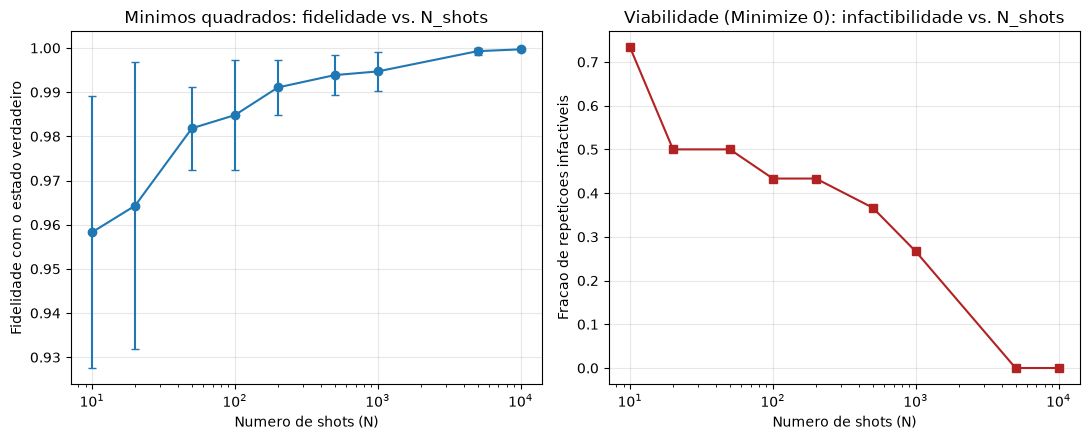

In [36]:
"""
Utilizar ruído para mostrar que o problema de viabilidade pode ser infactível, 
e que a versão de mínimos quadrados (convexa) ainda encontra uma boa aproximação.
"""

"""
Exemplo: efeito do ruido de shot-noise na tomografia via SDP.

Ideia: em vez de assumir que as medicoes q_i = Tr(Q_i rho) sao exatas,
simulamos que cada uma vem de N_shots medicoes binomiais (regra de Born).
Para N_shots pequeno, o problema de viabilidade (Minimize(0)) costuma ficar
infactivel; a versao de minimos quadrados sempre devolve uma resposta, e sua
fidelidade com o estado verdadeiro cresce conforme N_shots aumenta.

Ajuste os nomes de variaveis (Q, q, fidelidade, unk_state, mediadores_Q2 etc.)
para bater com o resto do seu notebook, se ja tiver essas coisas definidas la.
"""


rng = np.random.default_rng(42)

# --- 1. Estado "verdadeiro" que queremos recuperar (1 qubit) --------------
# Troque por unk_state.rho se ja tiver um estado definido no seu notebook.
d = 2
G = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
rho_true = G @ G.conj().T
rho_true /= np.trace(rho_true).real

sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
Q = [sx, sy, sz]           # troque por mediadores_Q2 se quiser reusar o seu
M = len(Q)

q_exato = np.array([np.trace(Qi @ rho_true).real for Qi in Q])

def medir_com_ruido(q_exato, N_shots, rng):
    """Simula N_shots medicoes binomiais por observavel (autovalores +-1)."""
    q_ruido = np.empty_like(q_exato)
    for i, qi in enumerate(q_exato):
        p_mais = (1 + qi) / 2
        outcomes = rng.binomial(N_shots, p_mais)
        q_ruido[i] = 2 * outcomes / N_shots - 1
    return q_ruido


def resolver_viabilidade(Q, q_ruido, d):
    rho_var = cp.Variable((d, d), hermitian=True)
    constraints = [rho_var >> 0, cp.trace(rho_var) == 1]
    for i in range(len(Q)):
        constraints.append(cp.real(cp.trace(Q[i] @ rho_var)) == q_ruido[i])
    problem = cp.Problem(cp.Minimize(0), constraints)
    problem.solve(solver=cp.SCS)
    return problem, rho_var


def resolver_minimos_quadrados(Q, q_ruido, d):
    rho_var = cp.Variable((d, d), hermitian=True)
    previsoes = cp.hstack([cp.real(cp.trace(Q[i] @ rho_var)) for i in range(len(Q))])
    problem = cp.Problem(
        cp.Minimize(cp.sum_squares(previsoes - q_ruido)),
        [rho_var >> 0, cp.trace(rho_var) == 1],
    )
    problem.solve(solver=cp.SCS)
    return problem, rho_var


N_shots_lista = [10, 20, 50, 100, 200, 500, 1000, 5000, 10000]
n_reps = 30

fidelidades_media = []
fidelidades_std = []
taxa_infactivel = []

for N_shots in N_shots_lista:
    fids = []
    n_infactivel = 0
    for _ in range(n_reps):
        q_ruido = medir_com_ruido(q_exato, N_shots, rng)

        prob_viab, _ = resolver_viabilidade(Q, q_ruido, d)
        if prob_viab.status != "optimal":
            n_infactivel += 1

        prob_ls, rho_ls = resolver_minimos_quadrados(Q, q_ruido, d)
        fids.append(fidelidade(rho_true, rho_ls.value))

    fidelidades_media.append(np.mean(fids))
    fidelidades_std.append(np.std(fids))
    taxa_infactivel.append(n_infactivel / n_reps)

    print(
        f"N_shots={N_shots:6d} | fidelidade media={np.mean(fids):.4f} "
        f"+- {np.std(fids):.4f} | infactivel em {n_infactivel}/{n_reps} repeticoes"
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.errorbar(N_shots_lista, fidelidades_media, yerr=fidelidades_std,
             marker="o", capsize=3)
ax1.set_xscale("log")
ax1.set_xlabel("Numero de shots (N)")
ax1.set_ylabel("Fidelidade com o estado verdadeiro")
ax1.set_title("Minimos quadrados: fidelidade vs. N_shots")
ax1.grid(alpha=0.3)

ax2.plot(N_shots_lista, taxa_infactivel, marker="s", color="firebrick")
ax2.set_xscale("log")
ax2.set_xlabel("Numero de shots (N)")
ax2.set_ylabel("Fracao de repeticoes infactiveis")
ax2.set_title("Viabilidade (Minimize 0): infactibilidade vs. N_shots")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("ruido_shot_noise_sdp.png", dpi=150)
plt.show()



In [ ]:
"""
Extensao do benchmark de tempo (Figura 2) para a formulacao via SDP.

Mesma logica do benchmark da parametrizacao: para cada numero de qubits,
gera um estado aleatorio, monta a base completa de Pauli (necessaria para
tomografia completa), calcula os valores esperados exatos e mede o tempo
que o solver leva para resolver o problema de viabilidade semidefinida.

Ajuste MAX_QUBITS com cuidado: o numero de observaveis (4^n - 1) e o
tamanho das matrizes (2^n x 2^n) crescem rapido, entao comece baixo (ex: 4)
e so aumente depois de ver quanto tempo os primeiros pontos levam.
"""

rng = np.random.default_rng(0)

I2 = np.eye(2, dtype=complex)
sx = np.array([[0, 1], [1, 0]], dtype=complex)
sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
sz = np.array([[1, 0], [0, -1]], dtype=complex)
PAULIS = {"I": I2, "X": sx, "Y": sy, "Z": sz}


def base_pauli_completa(n_qubits):
    """Gera os 4^n - 1 produtos tensoriais de Pauli (exclui a identidade global,
    que ja entra como a restricao de normalizacao Tr(rho) = 1)."""
    observaveis = []
    for combinacao in product("IXYZ", repeat=n_qubits):
        if combinacao == tuple("I" * n_qubits):
            continue
        Qi = PAULIS[combinacao[0]]
        for letra in combinacao[1:]:
            Qi = np.kron(Qi, PAULIS[letra])
        observaveis.append(Qi)
    return observaveis


def estado_aleatorio(d, rng):
    G = rng.normal(size=(d, d)) + 1j * rng.normal(size=(d, d))
    rho = G @ G.conj().T
    return rho / np.trace(rho).real


def resolver_viabilidade_sdp(Q, q, d):
    rho_var = cp.Variable((d, d), hermitian=True)
    constraints = [rho_var >> 0, cp.trace(rho_var) == 1]
    for i in range(len(Q)):
        constraints.append(cp.real(cp.trace(Q[i] @ rho_var)) == q[i])
    problem = cp.Problem(cp.Minimize(0), constraints)
    problem.solve(solver=cp.SCS)
    return problem


MAX_QUBITS = 4  # comece pequeno; cada +1 aumenta MUITO o tempo de execucao

tempos_sdp = []
n_qubits_lista = list(range(1, MAX_QUBITS + 1))

for n in n_qubits_lista:
    d = 2**n
    Q = base_pauli_completa(n)
    rho_alvo = estado_aleatorio(d, rng)
    q = [np.trace(Qi @ rho_alvo).real for Qi in Q]

    inicio = time.time()
    problem = resolver_viabilidade_sdp(Q, q, d)
    duracao = time.time() - inicio

    tempos_sdp.append(duracao)
    print(f"n_qubits={n} | d={d} | M={len(Q)} observaveis | "
          f"status={problem.status} | tempo={duracao:.3f}s")

# --- Grafico -------------------------------------------------------------
plt.figure(figsize=(7, 4.5))
plt.plot(n_qubits_lista, tempos_sdp, marker="o", label="SDP (viabilidade)")

# Se voce ja tem os tempos da parametrizacao (Figura 2) em uma lista,
# por exemplo `tempos_parametrizacao`, descomente e ajuste para sobrepor:
# plt.plot(n_qubits_lista, tempos_parametrizacao[:MAX_QUBITS],
#          marker="s", label="Parametrizacao (T dagger T)")

plt.xlabel("Numero de qubits (n)")
plt.ylabel("Tempo (s)")
plt.title("Tempo de execucao vs. numero de qubits - SDP")
plt.yscale("log")  # escala log ajuda a comparar com crescimento super-exponencial
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("benchmark_tempo_sdp.png", dpi=150)
plt.show()
